# Qualitative Analysis

A representative set of 10 runs: Progressive [60, 30, 10] | network 500a | seeds [1-10] | 30 days

This notebook investigates figures that build intuition for what the
model does before any formal statistical comparison. This approach mirrors the analysis of the paper by
Falandays et al. (2022), who analysed a cultural attractor ABM.

**Four figures in this notebook:**
1. Day 0 vs day 29 aggregate load curves (median across seeds + IQR shading)
2. Median daily load profile with price overlay (median across seeds + IQR pooled across seeds and days)
3. Price evolution heatmap across all 30 days (mean across seeds per cell)
4. Cumulative price-driven vs social-driven shift contributions per behavioral group (median + IQR across seeds)

All data is loaded from the cached "representative" runs from datagenerator.py. Found in results/representative/

## 1. Imports and setup

In [4]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

#point to the project root so datagenerator-related paths resolve correctly
project_root = Path(".")
sys.path.insert(0, str(project_root))

#set the folder where the representative runs were saved by datagenerator.py
repr_dir = Path("results/representative")

#set the folder where figures from this notebook will be saved
figure_dir = Path("figures/qualitative")
figure_dir.mkdir(parents=True, exist_ok=True)

#consistent visual style for all plots in this notebook
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9})



#build the 24-hour time axis for 96 quarter-hour slots (0:00 to 23:45)
time_axis = np.linspace(0, 24, 96, endpoint=False)

#total simulated days - must match what datagenerator.py used
days = 30

#the list of seeds that the representative section of datagenerator.py runs

repr_seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] 

print("representative run data expected in:", repr_dir)
print("will save figures to:", figure_dir)

representative run data expected in: results\representative
will save figures to: figures\qualitative


## 2. Load the representative run data

Loads all ten representative runs (one for every random state) into separate dictionaries
keyed by seed. The downstream figures aggregate across these seeds to show
the central tendency and run-to-run variability.

In [14]:
#store data per seed
runs_agents = {}
runs_daily = {}
runs_pricing = {}
runs_load = {}

for repr_seed in repr_seeds:
    agents_path = repr_dir / ("agents_seed" + str(repr_seed) + ".parquet") #follows my structure form the datagenerator
    daily_path = repr_dir / ("daily_seed" + str(repr_seed) + ".parquet")
    pricing_path = repr_dir / ("pricing_seed" + str(repr_seed) + ".parquet")
    load_path = repr_dir / ("load_seed" + str(repr_seed) + ".npy")

    runs_agents[repr_seed] = pd.read_parquet(agents_path)
    runs_daily[repr_seed] = pd.read_parquet(daily_path)
    runs_pricing[repr_seed] = pd.read_parquet(pricing_path)
    runs_load[repr_seed] = np.load(load_path)

#print a quick size check to confirm everything loaded as expected
print("data loaded successfully for", len(repr_seeds), "seeds")
print("per-seed shapes (using seed", repr_seeds[0], "as example):")
print("df_agents shape:", runs_agents[repr_seeds[0]].shape, "(one row per agent per day)")
print("df_daily shape:", runs_daily[repr_seeds[0]].shape, "(one row per simulated day)")
print("load_profiles shape:", runs_load[repr_seeds[0]].shape, "(days x 96 quarter-hour slots)")
print("df_pricing shape:", runs_pricing[repr_seeds[0]].shape)
print()

#show how many agents belong to each behavioral group (using the first seed for reference, same for all)
ref_agents = runs_agents[repr_seeds[0]]
day0_agents = ref_agents[ref_agents["day"] == 0] #day doesnt matte rbecause agents don't switch their behavioral group
group_counts = day0_agents["dominant_group"].value_counts()
print("agent group composition in this run:")
for group_name in group_counts.index:
    count = group_counts[group_name]
    print(" ", group_name, ":", count, "agents")

data loaded successfully for 10 seeds
per-seed shapes (using seed 1 as example):
df_agents shape: (15000, 16) (one row per agent per day)
df_daily shape: (30, 32) (one row per simulated day)
load_profiles shape: (30, 96) (days x 96 quarter-hour slots)
df_pricing shape: (720, 5)

agent group composition in this run:
  Habit-driven : 300 agents
  Price-responsive : 150 agents
  Social-influenced : 50 agents


## 3. Figure 1: day 0 vs day 29 aggregate load curves

Compare the aggregate load curve (sum of all agent loads at each quarter-hour
slot) on the first day of the simulation (day 0) and on the last day (day 29).
Day 0 has only the habit-driven shift applied at initialisation, day 29 has
had 29 cycles of price and social shifting on top.

**The solid line is the median across the 10 seeds and the shaded band is
the interquartile range across seeds. RED = Day 29, BLUE = day 0** 

A visible difference between the two curves is the most basic confirmation that behavioral shifting actually does
something to the daily load shape, and the bands show how stable that
difference is across runs.

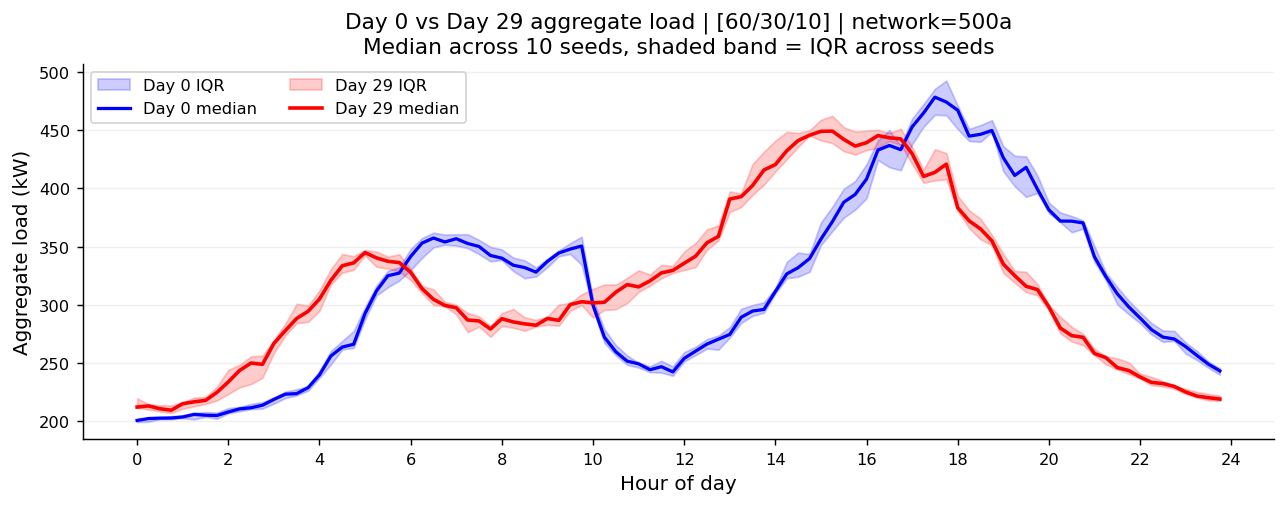

In [49]:
#stack day 0 curves from every seed into a 2D array
day0_list = []
day29_list = []
for repr_seed in repr_seeds:
    loads = runs_load[repr_seed]
    day0_list.append(loads[0])
    day29_list.append(loads[-1])
day0_stack = np.array(day0_list)
day29_stack = np.array(day29_list)

#median and IQR across the seed axis
day0_median = np.median(day0_stack, axis=0)
day0_q25 = np.percentile(day0_stack, 25, axis=0)
day0_q75 = np.percentile(day0_stack, 75, axis=0)

day29_median = np.median(day29_stack, axis=0)
day29_q25 = np.percentile(day29_stack, 25, axis=0)
day29_q75 = np.percentile(day29_stack, 75, axis=0)

fig, ax = plt.subplots(figsize=(10, 4))

#plot day 0 with IQR band
ax.fill_between(time_axis, day0_q25, day0_q75,
                alpha=0.2, color="blue", label="Day 0 IQR")
ax.plot(time_axis, day0_median,
        color="blue", linewidth=1.8, label="Day 0 median")

#plot day 29 with IQR band
ax.fill_between(time_axis, day29_q25, day29_q75,
                alpha=0.2, color="red", label="Day 29 IQR")
ax.plot(time_axis, day29_median,
        color="red", linewidth=2, label="Day 29 median")

#axis labels and formatting
ax.set_xlabel("Hour of day")
ax.set_ylabel("Aggregate load (kW)")
#CHANGE: subtitle updated to reflect 10-seed aggregation
ax.set_title("Day 0 vs Day 29 aggregate load | [60/30/10] | network=500a\n"
             "Median across 10 seeds, shaded band = IQR across seeds")
ax.set_xticks(range(0, 25, 2))
ax.legend(loc="upper left", ncol=2)
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.savefig(figure_dir / "fig1_day0_vs_day29.png", bbox_inches="tight")
plt.show()


## 4. Figure 2: median daily load profile with price overlay

Show the typical daily load shape across all 30 days as a median 96-slot curve
with an interquartile range band. Overlay the median hourly price across the days to see how
it mirrors the demand structure. Goes by hour so will be a bit more spikey.

**The IQR band now pools across both days and seeds** (10 seeds × 30 days =
300 daily curves), so it captures both within-run variability across days and
between-run variability across seeds

Gives a good insight into the correlation between price and demand in my model

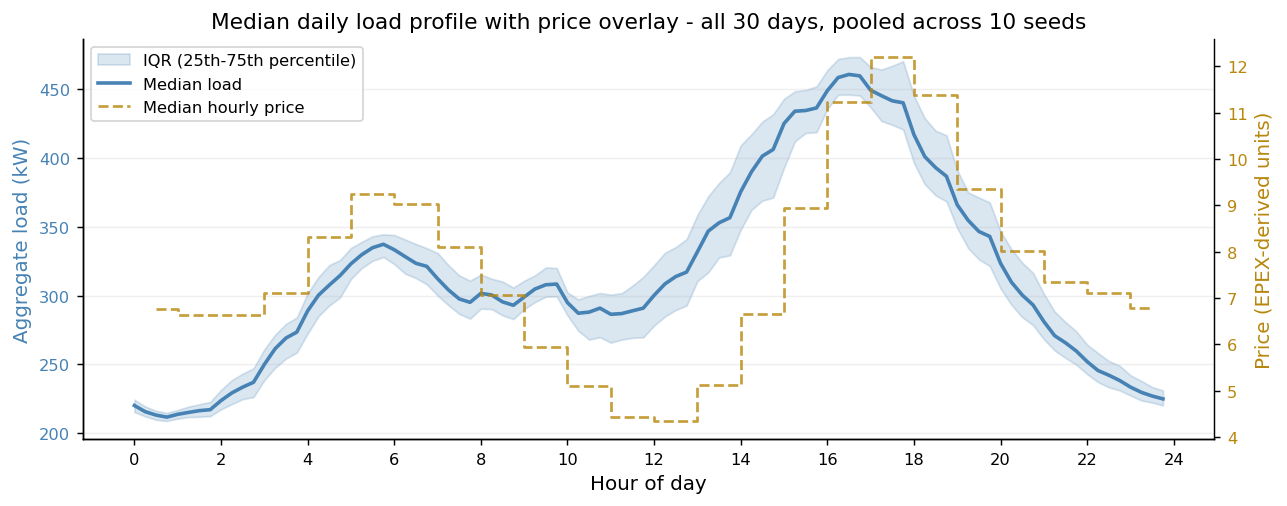

In [72]:
#get the load profiles for all days and seeds
lp_pool_list = []
for repr_seed in repr_seeds:
    lp = runs_load[repr_seed]
    for day_i in range(lp.shape[0]):
        lp_pool_list.append(lp[day_i])
lp_pool = np.array(lp_pool_list)

#element-wise median and quartile bands across the pooled (seed x day) axis
lp_median = np.median(lp_pool, axis=0)
lp_q25 = np.percentile(lp_pool, 25, axis=0)
lp_q75 = np.percentile(lp_pool, 75, axis=0)

#CHANGE: median price per hour now computed across all seeds and all 30 days
#  -> for each hour collect prices from every (seed, day) and take the median
price_by_hour = {}
for hour_val in range(24):
    hour_prices_all = []
    for repr_seed in repr_seeds:
        df_pricing = runs_pricing[repr_seed]
        hp = df_pricing[df_pricing["hour"] == hour_val]["price_used"].values
        for v in hp:
            hour_prices_all.append(v)
    if len(hour_prices_all) > 0:
        price_by_hour[hour_val] = float(np.median(hour_prices_all))

#assemble the price arrays explicitly with for loops
price_x = []
price_y = []
for hour_val in sorted(price_by_hour.keys()):
    price_x.append(hour_val)
    price_y.append(price_by_hour[hour_val])
price_x = np.array(price_x)
price_y = np.array(price_y)

#create figure with two y-axes
fig, ax1 = plt.subplots(figsize=(10, 4))

#plot interquartile range band and median load on the left axis
ax1.fill_between(time_axis, lp_q25, lp_q75,
                 color="steelblue", alpha=0.2, label="IQR (25th-75th percentile)")
ax1.plot(time_axis, lp_median,
         color="steelblue", linewidth=2, label="Median load")
ax1.set_xlabel("Hour of day")
ax1.set_ylabel("Aggregate load (kW)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_xticks(range(0, 25, 2))

#plot median price on the right axis
ax2 = ax1.twinx()
ax2.step(price_x + 0.5, price_y, where="mid",
         color="darkgoldenrod", linewidth=1.5, linestyle="--", alpha=0.8,
         label="Median hourly price")
ax2.set_ylabel("Price (EPEX-derived units)", color="darkgoldenrod")
ax2.tick_params(axis="y", labelcolor="darkgoldenrod")
ax2.spines["right"].set_visible(True)

#combine legends from both axes into one
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
all_lines = lines1 + lines2
all_labels = labels1 + labels2
ax1.legend(all_lines, all_labels, loc="upper left")

#CHANGE: title updated to reflect pooled-seed aggregation
ax1.set_title("Median daily load profile with price overlay - all 30 days, pooled across 10 seeds")
ax1.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(figure_dir / "fig2_median_load_price.png", bbox_inches="tight")
plt.show()

## 5. Figure 3: price evolution heatmap

Each cell shows the price at a given hour on a given day across the 30 simulated
days. **Cells are the mean across the 10 seeds**, so the heatmap shows
the typical price evolution rather than a single sample.

Reading down a column shows the price shape on that day; reading across
a row shows how a given hour's price evolves over time.

If shifting successfully moves load away from expensive hours, those hours
should gradually become cheaper as demand drops.

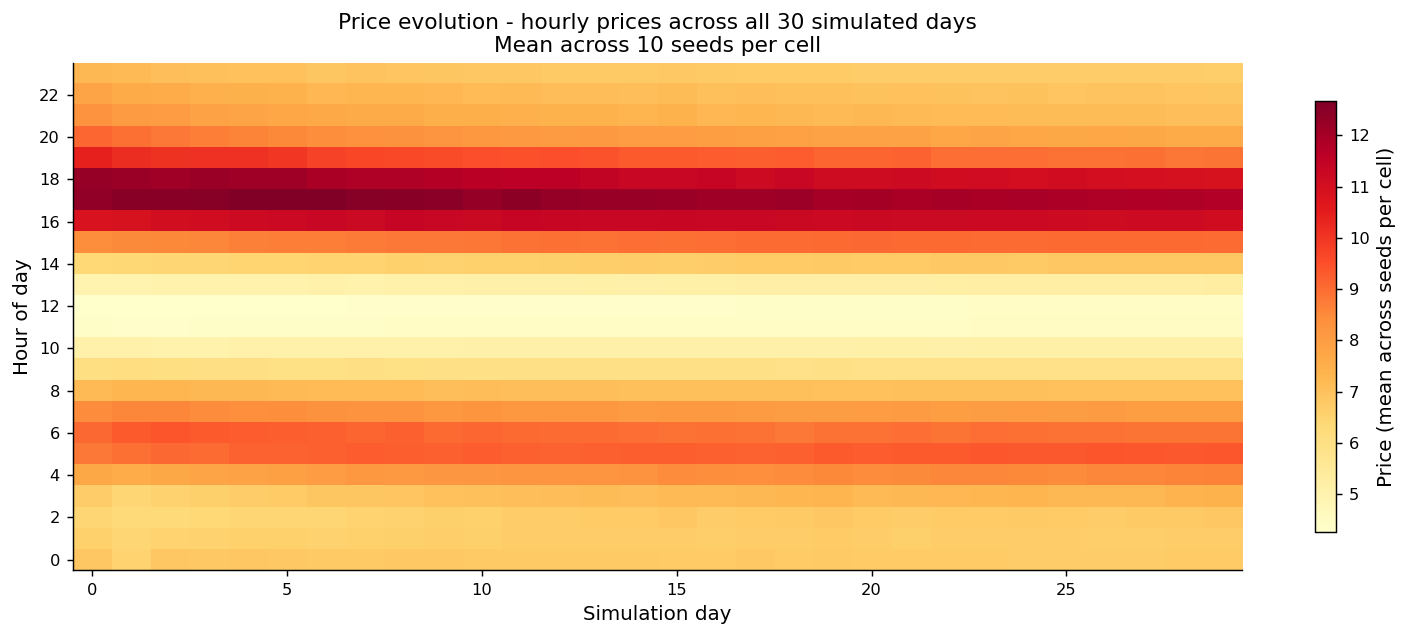

In [99]:
price_matrix = np.full((24, days), np.nan)

#fill the matrix by iterating over every (day, hour) cell
for day_val in range(days):
    for hour_val in range(24):
        cell_vals = []
        for seed in repr_seeds:
            df_pricing = runs_pricing[seed]
            cell = df_pricing[(df_pricing["day"] == day_val) & (df_pricing["hour"] == hour_val)]["price_used"]
            if len(cell) > 0:
                cell_vals.append(float(cell.iloc[0]))
        if len(cell_vals) > 0:
            price_matrix[hour_val, day_val] = float(np.mean(cell_vals))

#create the heatmap
fig, ax = plt.subplots(figsize=(12, 5))

im = ax.imshow(price_matrix, aspect="auto", cmap="YlOrRd",
               origin="lower",
               extent=[-0.5, days - 0.5, -0.5, 23.5])

cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("Price (mean across seeds per cell)")

ax.set_xlabel("Simulation day")
ax.set_ylabel("Hour of day")

ax.set_title("Price evolution - hourly prices across all 30 simulated days\n"
             "Mean across 10 seeds per cell")
ax.set_yticks(range(0, 24, 2))
ax.set_xticks(range(0, days, 5))

plt.tight_layout()
plt.savefig(figure_dir / "fig3_price_heatmap.png", bbox_inches="tight")
plt.show()

## 6. Figure 4: cumulative shift contributions by behavioral group

For each behavioral group, keep track the cumulative of price-driven and
social-driven shift contributions across the 30 days, averaged across agents
in the group.

**The solid line is the median across the 10 seeds and the shaded band is
the interquartile range across seeds**, separately for the price and social
shift contributions.

If the model works as designed:
- Habit-driven agents should accumulate very little through either channel when compared to soc_suc and price_responsive
- Price-responsive agents should be dominated by the price channel
- Social-influenced agents should be dominated by the social channel

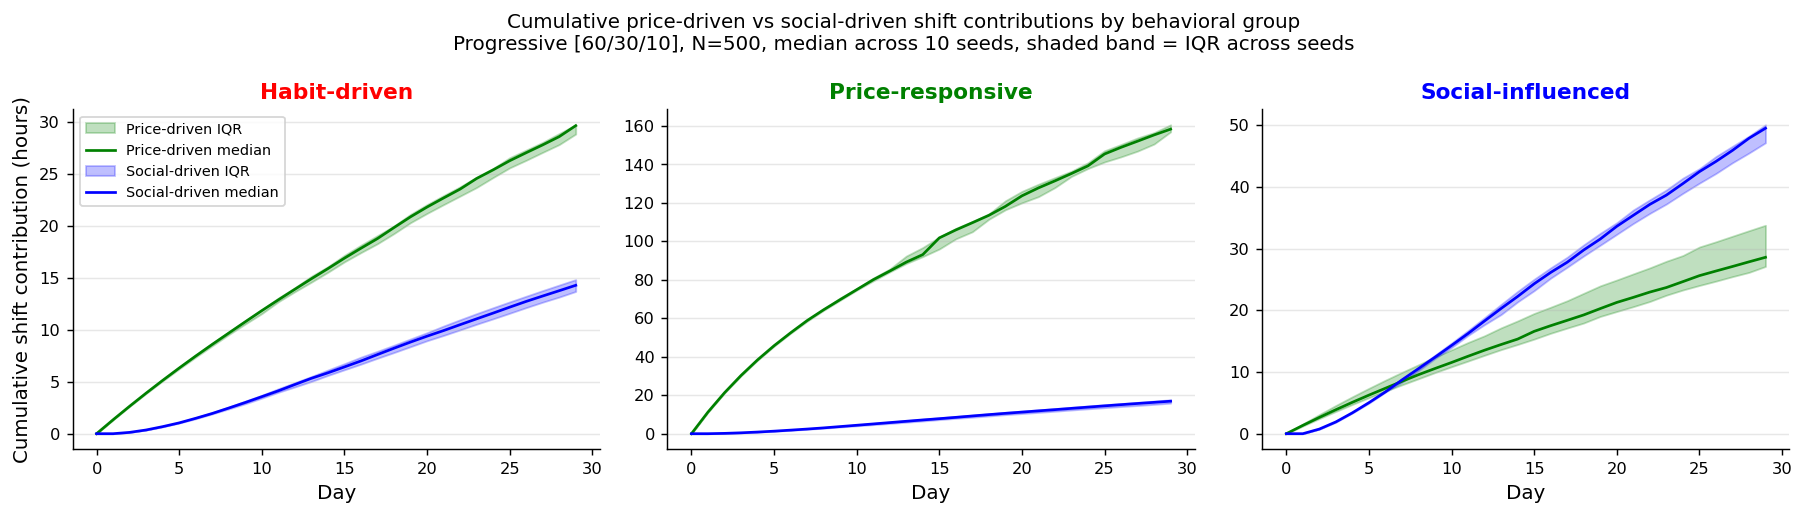

figure 4 saved


In [113]:
groups_list = ["Habit-driven", "Price-responsive", "Social-influenced"]
channels_list = ["price", "social"]

group_colors = {
    "Habit-driven": "red",
    "Price-responsive": "green",
    "Social-influenced": "blue"}

per_seed_cum = {}
for group_name in groups_list:
    per_seed_cum[group_name] = {}
    for channel in channels_list:
        per_seed_cum[group_name][channel] = []

#for each seed compute the per-day mean contribution per group then convert to the cumulative trajectory
for repr_seed in repr_seeds:
    df_active = runs_agents[repr_seed].copy()

    #compute mean price and social contributions per group per day for this seed
    seed_rows = []
    for day_val in sorted(df_active["day"].unique()):
        day_data = df_active[df_active["day"] == day_val]
        for group_name in groups_list:
            group_data = day_data[day_data["dominant_group"] == group_name]
            if len(group_data) > 0:
                row = {
                    "day": day_val,
                    "dominant_group": group_name,
                    "price_shift_contribution": group_data["price_shift_contribution"].mean(),
                    "social_shift_contribution": group_data["social_shift_contribution"].mean()}
                seed_rows.append(row)
    seed_df = pd.DataFrame(seed_rows)
    seed_df = seed_df.sort_values(["dominant_group", "day"])

    #for each group build the cumulative trajectory for both channels and store under this seed
    for group_name in groups_list:
        group_subset = seed_df[seed_df["dominant_group"] == group_name].copy()
        group_subset = group_subset.sort_values("day")
        price_vals = group_subset["price_shift_contribution"].values
        social_vals = group_subset["social_shift_contribution"].values

        #build the cumulative sum arrays  
        cum_price = np.zeros(len(price_vals))
        cum_social = np.zeros(len(social_vals))
        cum_price[0] = price_vals[0]
        cum_social[0] = social_vals[0]
        for i in range(1, len(price_vals)):
            cum_price[i] = cum_price[i - 1] + price_vals[i]
            cum_social[i] = cum_social[i - 1] + social_vals[i]

        per_seed_cum[group_name]["price"].append(cum_price)
        per_seed_cum[group_name]["social"].append(cum_social)

#convert each list of per-seed trajectories into a 2D array (n_seeds, days) for aggregation
agg_cum = {}
for group_name in groups_list:
    agg_cum[group_name] = {}
    for channel in channels_list:
        agg_cum[group_name][channel] = np.array(per_seed_cum[group_name][channel])

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

#x-axis is day index from 0 to days-1
x_vals = np.arange(days)

for ax_i, group_name in enumerate(groups_list):
    ax = axes[ax_i]

    #compute median and IQR across seeds for both channels
    price_arr = agg_cum[group_name]["price"]
    social_arr = agg_cum[group_name]["social"]

    price_med = np.median(price_arr, axis=0)
    price_q25 = np.percentile(price_arr, 25, axis=0)
    price_q75 = np.percentile(price_arr, 75, axis=0)

    social_med = np.median(social_arr, axis=0)
    social_q25 = np.percentile(social_arr, 25, axis=0)
    social_q75 = np.percentile(social_arr, 75, axis=0)

    #fill IQR band for the price channel
    ax.fill_between(x_vals, price_q25, price_q75,
                    alpha=0.25, color="green", label="Price-driven IQR")
    #median line for the price channel
    ax.plot(x_vals, price_med, color="green", linewidth=1.5, label="Price-driven median")

    #fill IQR band for the social channel
    ax.fill_between(x_vals, social_q25, social_q75,
                    alpha=0.25, color="blue", label="Social-driven IQR")
    #median line for the social channel
    ax.plot(x_vals, social_med, color="blue", linewidth=1.5, label="Social-driven median")

    #per-panel formatting
    ax.set_title(group_name, color=group_colors[group_name], fontweight="bold")
    ax.set_xlabel("Day")
    if ax_i == 0:
        ax.set_ylabel("Cumulative shift contribution (hours)")
    ax.set_xticks(range(0, days + 1, 5))
    ax.grid(axis="y", alpha=0.3)
    if ax_i == 0:
        ax.legend(fontsize=8)

fig.suptitle(
    "Cumulative price-driven vs social-driven shift contributions per behavioral group\n"
    "Progressive [60/30/10] | network=500a | median across 10 seeds, shaded band = IQR across seeds",
    fontsize=11)
plt.tight_layout()
plt.savefig(figure_dir / "fig4_cumulative_shift_contributions.png", bbox_inches="tight")
plt.show()
print("figure 4 saved")

## Summary w/ simple analysis

The four figures above give the qualitative picture of the model's behavior:

- **Figure 1** shows whether 29 days of behavioral shifting visibly deforms the load curve compared to day 0

  -> Shows a clear shift in this progressive case, variance can be somewhat high at initialisation at the peaks specifically, but eventually evens out
  across random states

- **Figure 2** shows the typical daily shape and whether the population aligns its load with cheap hours

  -> The correlation between price and demand is as expected, high demand = high price, low demand = low price. It lines up well

- **Figure 3** shows how prices evolve day by day as aggregate demand shifts

  -> Peak hours are dark but slowly get lighter as the days progress. The dark tint moves a bit downwards as well, showing where the demand has been shifting towards

- **Figure 4** validates the behavioral architecture: each group accumulates
  shifts through the channel it should

  -> Price is a no noise shift and will be high always, hence the punishing epsilon. The social influence shows that social influence becomes higher as more and more agents join the “price-responsive” team, being a realistic and desired outcome